# Калибровка моделей PD: сравнение методов с акцентом на сплайн-калибровку

In [ ]:
import sys
sys.path.append("..")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from IPython.display import display
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import roc_auc_score

from data.generate_data import generate_credit_data, get_oot_split, portfolio_summary
from src.calibrators import get_all_calibrators
from src.metrics import (
    brier_score,
    bootstrap_ci,
    discrimination_metrics,
    fixed_bin_table,
    get_calibration_curve,
    summary_metrics,
)
from src.capital import IRBAssumptions, compare_irb_capital_by_method, calculate_irb_capital

plt.rcParams["figure.dpi"] = 120
plt.rcParams["font.size"] = 11
sns.set_style("whitegrid")
COLORS = ["#e74c3c", "#2980b9", "#27ae60", "#e67e22", "#8e44ad", "#16a085"]
RANDOM_STATE = 42

print("Imports and project modules loaded.")

## 1. Постановка исследования и критерии сравнения

В рамках **Basel III / IRB-подхода** калибровка PD нужна не только для того, чтобы прогнозные вероятности совпадали с наблюдаемыми дефолтами по бинам риска, но и для того, чтобы итоговая оценка кредитного риска не искажала **резервы, RWA и требуемый капитал**. Поэтому в работе сравниваются не только графики калибровки, но и прикладной эффект от того, как каждый метод перераспределяет PD по шкале риска.

В исследовании сопоставляются шесть вариантов оценки PD на одной и той же базовой модели: **RF без калибровки**, **логит-калибровка**, **изотоническая регрессия**, **бета-калибровка**, **сплайн-калибровка** и **французский сплайн-калибровка**. Под сплайн-калибровкой понимается **монотонный гладкий сплайн**. Под **французским сплайном** понимается двухшаговая схема по мотивам подхода Banque de France / ICAS: сначала исходные PD калибруются логит-моделью, а затем логит-калиброванные PD дополнительно сглаживаются сплайном.

**Цель исследования** — определить, какой способ калибровки даёт наиболее обоснованное распределение PD по всей шкале риска и как это отражается на прикладном результате: величине **Reserves**, **RWA**, **требуемого капитала при H1 = 8%** и **экономии капитала относительно сырых PD**.

**Критерии сравнения** разделены на две группы:
- **статистические**: Brier Score, Log-Loss, ECE, HL p-value, а также визуальная согласованность PD с фактическими дефолтами по reliability-diagram и по фиксированным бинам `[0.0–0.1], …, [0.9–1.0]`;
- **прикладные**: итоговые **Reserves**, **имплицитный RWA**, **требуемый капитал при H1 = 8%**, **экономия капитала относительно сырых PD** и уровень **H1**, если сохранить капитал, достаточный для сырых PD.

Для сопоставимости прикладной части принимаются фиксированные допущения: **EAD = 1 000 000** для каждого наблюдения и **LGD = 40%**. Поэтому различия в итоговом капитале интерпретируются как эффект именно от выбора метода калибровки PD.

## 2. Данные: синтетический кредитный портфель

In [2]:
df = generate_credit_data(n_samples=40000, random_state=RANDOM_STATE)

print(f"Датасет: {df.shape[0]:,} строк | {df.shape[1]} столбцов")
print(f"Общая доля дефолтов: {df['default'].mean():.2%}")
print(f"Средняя истинная PD в синтетике: {df['true_pd'].mean():.2%}\n")

true_pd_stats = df["true_pd"].describe(percentiles=[0.50, 0.90, 0.95, 0.99])[["min", "50%", "90%", "95%", "99%", "max"]]
print("Распределение истинной PD в портфеле:")
print(true_pd_stats.map(lambda x: f"{x:.2%}"))

segment_stats = (
    df.groupby("risk_segment")
      .agg(наблюдений=("default", "count"), доля_дефолтов=("default", "mean"), средняя_true_pd=("true_pd", "mean"))
)
segment_map = {0: "0 = prime", 1: "1 = standard", 2: "2 = subprime", 3: "3 = distressed"}
segment_stats.index = segment_stats.index.map(segment_map)
segment_stats["доля_дефолтов"] = segment_stats["доля_дефолтов"].map("{:.2%}".format)
segment_stats["средняя_true_pd"] = segment_stats["средняя_true_pd"].map("{:.2%}".format)
print("\nРиск-сегменты синтетического портфеля:")
print(segment_stats)

by_year = df.groupby("origination_year")["default"].agg(всего="count", дефолтов="sum", доля="mean")
by_year["доля"] = by_year["доля"].map("{:.2%}".format)
print("\nДефолты по годам выдачи:")
print(by_year)

display(df.drop(columns=["default", "origination_year", "risk_segment", "true_pd"]).describe().round(2))

Датасет: 40,000 строк | 12 столбцов
Общая доля дефолтов: 13.79%
Средняя истинная PD в синтетике: 13.80%

Распределение истинной PD в портфеле:
min     0.23%
50%     1.80%
90%    51.85%
95%    83.53%
99%    95.84%
max    99.58%
Name: true_pd, dtype: str

Риск-сегменты синтетического портфеля:
                наблюдений доля_дефолтов средняя_true_pd
risk_segment                                            
0 = prime            15119         0.71%           0.64%
1 = standard         13601         2.57%           2.66%
2 = subprime          8082        29.25%          29.45%
3 = distressed        3198        84.24%          83.88%

Дефолты по годам выдачи:
                  всего  дефолтов    доля
origination_year                         
2019               5513       739  13.40%
2020               5576       864  15.49%
2021               7219       983  13.62%
2022               7275       964  13.25%
2023               8045      1021  12.69%
2024               6372       944  14.81%


,credit_score,ltv,dti,employment_years,loan_amount,loan_term,num_delinquencies,loan_purpose
count,40000.00,40000.00,40000.00,40000.00,40000.00,40000.00,40000.00,40000.00
mean,654.48,0.42,0.30,6.38,221.19,45.94,0.51,1.00
std,117.18,0.23,0.20,4.25,229.40,24.13,0.90,0.88
min,300.00,0.05,0.03,0.00,14.80,12.00,0.00,0.00
25%,578.00,0.23,0.13,3.00,103.78,24.00,0.00,0.00
50%,677.00,0.38,0.24,6.00,156.30,48.00,0.00,1.00
75%,747.00,0.61,0.43,9.30,256.40,60.00,1.00,2.00
max,850.00,0.95,0.87,23.90,9119.70,120.00,8.00,2.00


## 3. Экспериментальный протокол и схема выборок

В эксперименте используется **out-of-time схема**, близкая к банковской практике валидации:
- **Train (2019–2021)** — обучение базовой модели;
- **Calibration (2022–2023)** — обучение калибраторов только на сырых score базовой модели;
- **Test OOT (2024)** — финальная оценка качества калибровки и капитального эффекта на будущих данных.

Базовая модель оценивается один раз на train-периоде. Затем её score на calibration-выборке подаются на вход каждому калибратору. Откалиброванные PD применяются только к OOT-выборке 2024 года.

Важно, что **test OOT не используется для настройки параметров калибраторов**. Для финальной сплайн-калибровки используется только монотонный гладкий вариант без подбора по тестовой выборке, чтобы избежать утечки информации из test в модельный выбор.

In [3]:
X_train, X_calib, X_test, y_train, y_calib, y_test = get_oot_split(df)

print("Out-of-Time разбивка:")
print(f"  Train       (2019-2021): {len(X_train):,} строк | дефолты: {y_train.mean():.2%}")
print(f"  Calibration (2022-2023): {len(X_calib):,} строк | дефолты: {y_calib.mean():.2%}")
print(f"  Test OOT    (2024):      {len(X_test):,} строк  | дефолты: {y_test.mean():.2%}")

Out-of-Time разбивка:
  Train       (2019-2021): 18,308 строк | дефолты: 14.12%
  Calibration (2022-2023): 15,320 строк | дефолты: 12.96%
  Test OOT    (2024):      6,372 строк  | дефолты: 14.81%


## 4. Базовая модель и исходное качество некалиброванных PD

In [4]:
base_model = RandomForestClassifier(
    n_estimators=300,
    max_depth=7,
    min_samples_leaf=20,
    random_state=RANDOM_STATE,
    n_jobs=-1,
)
base_model.fit(X_train, y_train)

scores_calib = np.clip(base_model.predict_proba(X_calib)[:, 1], 1e-6, 1 - 1e-6)
scores_test  = np.clip(base_model.predict_proba(X_test)[:, 1], 1e-6, 1 - 1e-6)

print(f"Диапазон скоров RF на OOT: [{scores_test.min():.4f}, {scores_test.max():.4f}]")
print(f"Медиана скоров RF:         {np.median(scores_test):.4f}")
print(f"90 / 95 / 99 перцентили:   {np.quantile(scores_test, [0.90, 0.95, 0.99]).round(4)}")
print(f"Скоры > 0.5:               {(scores_test > 0.5).mean():.1%}")

Диапазон скоров RF на OOT: [0.0070, 0.9652]
Медиана скоров RF:         0.0227
90 / 95 / 99 перцентили:   [0.5068 0.7538 0.9083]
Скоры > 0.5:               10.2%


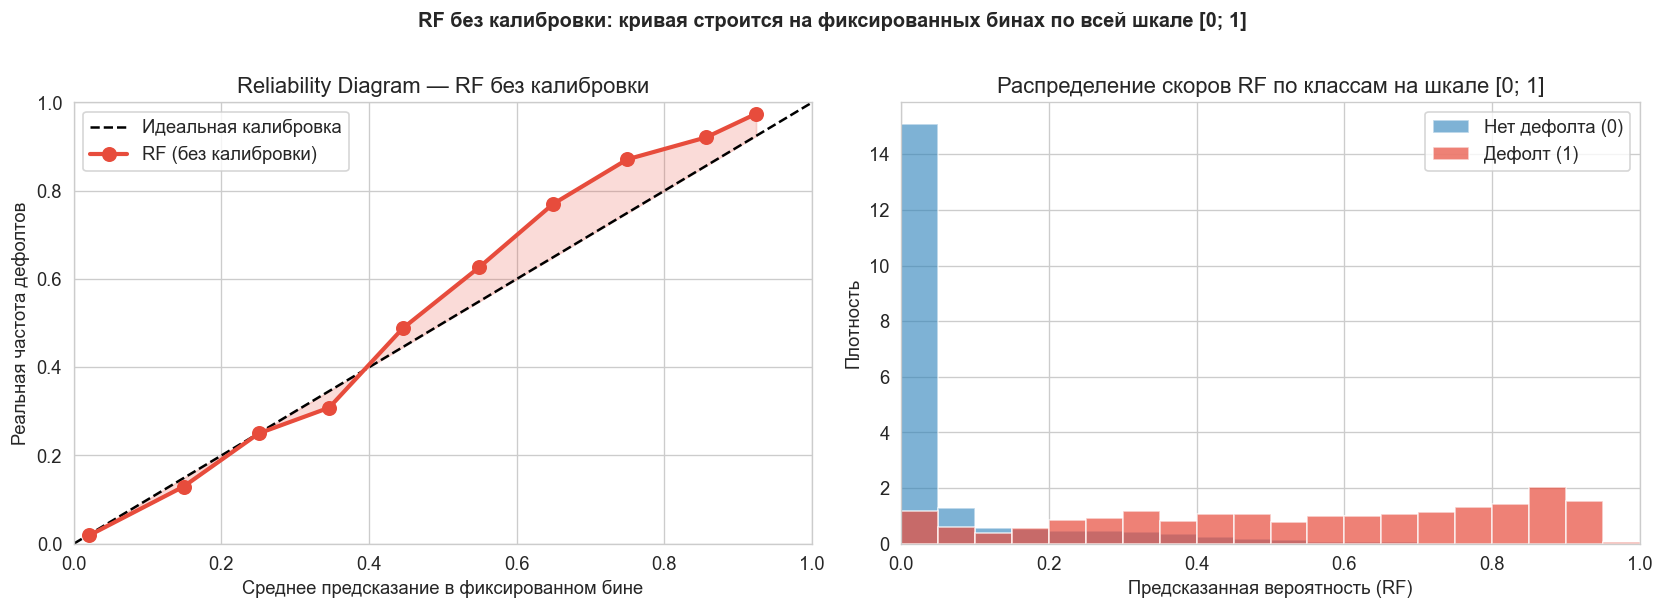

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax = axes[0]
mean_pred, frac_pos = get_calibration_curve(y_test.values, scores_test, n_bins=10, strategy="uniform")
ax.plot([0, 1], [0, 1], "k--", lw=1.5, label="Идеальная калибровка")
ax.plot(mean_pred, frac_pos, "o-", color=COLORS[0], lw=2.5, ms=8, label="RF (без калибровки)")
ax.fill_between(mean_pred, mean_pred, frac_pos, alpha=0.2, color=COLORS[0])
ax.set_xlabel("Среднее предсказание в фиксированном бине")
ax.set_ylabel("Реальная частота дефолтов")
ax.set_title("Reliability Diagram — RF без калибровки")
ax.legend()

x_max = max(scores_test.max() * 1.1, 0.35)
y_max = max(frac_pos.max() * 1.15, 0.35)
ax.set_xlim(0, min(x_max, 1.0))
ax.set_ylim(0, min(y_max, 1.0))

ax = axes[1]
ax.hist(scores_test[y_test == 0], bins=np.linspace(0, 1, 21), alpha=0.6, label="Нет дефолта (0)", color=COLORS[1], density=True)
ax.hist(scores_test[y_test == 1], bins=np.linspace(0, 1, 21), alpha=0.7, label="Дефолт (1)", color=COLORS[0], density=True)
ax.set_xlim(0, 1)
ax.set_xlabel("Предсказанная вероятность (RF)")
ax.set_ylabel("Плотность")
ax.set_title("Распределение скоров RF по классам на шкале [0; 1]")
ax.legend()

plt.suptitle(
    "RF без калибровки: кривая строится на фиксированных бинах по всей шкале [0; 1]",
    fontsize=12, fontweight="bold", y=1.01
)
plt.tight_layout()
plt.show()


## 5. Сравнение методов калибровки

В итоговом сравнении оставлена **одна базовая сплайн-модель** — **сплайн-калибровка с монотонным ограничением**.  
Причина: для PD-калибровки монотонность является содержательно предпочтительной, поскольку более высокий исходный риск не должен переводиться в более низкую итоговую PD.

Дополнительно вводится **французский сплайн-калибровка** — двухшаговый метод, в котором:
1. исходные PD сначала калибруются **логит-моделью**;
2. затем полученные логит-калиброванные PD дополнительно сглаживаются **монотонным сплайном**.

Таким образом, в ноутбуке сопоставляются простые параметрические, непараметрические и гибридные методы калибровки PD.

In [6]:
calibrators = get_all_calibrators()
calibrated_probs = {}

for name, cal in calibrators.items():
    cal.fit(scores_calib, y_calib.values)
    calibrated_probs[name] = np.clip(cal.predict(scores_test), 1e-6, 1 - 1e-6)
    print(f"{name}: обучен.")

print("\nВсе калибраторы обучены только на calibration-выборке.")

Логит-калибровка: обучен.
Изотоническая регрессия: обучен.
Бета-калибровка: обучен.
Сплайн-калибровка: обучен.
Французский сплайн калибровка: обучен.

Все калибраторы обучены только на calibration-выборке.


## 6. Результаты на OOT: метрики и визуальная диагностика

**Важно для интерпретации графиков.**  
Кривые калибровки в этой версии строятся на **фиксированных бинах по всей шкале [0; 1]**.  
Это исправляет прежнюю проблему, когда при квантильной разбивке последняя точка на оси X показывала лишь **среднее значение верхнего дециля**, поэтому визуально казалось, что все методы обрываются около `0.15`, хотя фактические максимумы PD были выше.

In [ ]:
results = [summary_metrics(y_test.values, scores_test, name="RF raw")]
for name, probs in calibrated_probs.items():
    results.append(summary_metrics(y_test.values, probs, name=name))

df_results = pd.DataFrame(results).set_index("method")

print("OOT metrics, test year 2024:")
print("  Brier, Log-Loss, ECE: lower is better")
print("  HL p-value: higher is better, but the test is often too strict for large samples")
print("  Slope ~ 1, Intercept ~ 0: closer to ideal calibration")

display(
    df_results.round({
        "brier_score": 5,
        "log_loss": 5,
        "ece_uniform": 5,
        "ece_quantile": 5,
        "hl_chi2": 3,
        "hl_p_value": 4,
        "cal_slope": 4,
        "cal_intercept": 4,
    })
)

disc_rows = []
all_preds = {"RF raw": scores_test, **calibrated_probs}
for name, probs in all_preds.items():
    disc_rows.append(discrimination_metrics(y_test.values, probs, name=name))

df_disc = pd.DataFrame(disc_rows).set_index("method")
print("\nRanking metrics (AUC / Gini / KS):")
print(df_disc.to_string())
print("\nStrictly monotone transformations usually preserve ranking;")
print("isotonic and spline methods can change AUC/Gini slightly because of ties or smoothing.")

prob_range_rows = []
for name, probs in all_preds.items():
    prob_range_rows.append({
        "method": name,
        "min_pd": np.min(probs),
        "p95_pd": np.quantile(probs, 0.95),
        "max_pd": np.max(probs),
    })

df_prob_ranges = pd.DataFrame(prob_range_rows).set_index("method")
print("\nObserved PD range on OOT:")
display(df_prob_ranges.round(4))

### Эффект калибровки на резервы, RWA и требуемый капитал

После статистического сравнения каждая версия PD переводится в прикладные показатели: **Reserves**, **имплицитный RWA**, **требуемый капитал при H1 = 8%** и **Capital_true**. Это позволяет оценить не только качество калибровки как статистической процедуры, но и её влияние на капитальную нагрузку портфеля.

Для чистоты сравнения используется фиксированное допущение **EAD = 1 000 000** на каждое наблюдение и **LGD = 40%**. Поэтому различия между методами интерпретируются как эффект именно от калиброванной **PD**, а не от разного размера экспозиции.

Дополнительно рассчитывается, сколько капитала можно высвободить относительно **сырых PD** при целевом нормативе **H1 = 8%**, а также каким станет фактический **H1**, если сохранить капитал, достаточный для некалиброванной базовой модели.

In [ ]:
pred_map = {"RF raw": scores_test, **calibrated_probs}

capital_assumptions = IRBAssumptions(
    lgd=0.40,
    maturity_years=2.5,
    ead=1_000_000.0,
)

df_rwa = compare_irb_capital_by_method(
    pred_map,
    assumptions=capital_assumptions,
    baseline_method="RF raw",
)

base_required_capital = df_rwa.loc["RF raw", "total_required_capital"]
df_rwa["h1_if_keep_raw_capital"] = base_required_capital / df_rwa["total_rwa"]
df_rwa["h1_uplift_vs_raw"] = df_rwa["h1_if_keep_raw_capital"] - capital_assumptions.capital_ratio

df_rwa = df_rwa.sort_values("total_required_capital")

print(f"Fixed EAD per observation = {capital_assumptions.ead:,.0f}")
print(f"LGD = {capital_assumptions.lgd:.0%}, M = {capital_assumptions.maturity_years:.1f}, capital ratio = {capital_assumptions.capital_ratio:.0%}")
print("RWA = unexpected-loss capital / 8%, i.e. Basel-style K * EAD * 12.5.\n")

display_cols = [
    "avg_pd",
    "total_ead",
    "total_expected_loss",
    "total_unexpected_loss_capital",
    "total_rwa",
    "total_required_capital",
    "rwa_saving_vs_baseline_pct",
    "capital_saving_vs_baseline_pct",
    "h1_if_keep_raw_capital",
]

df_rwa_display = df_rwa[display_cols].copy()
for c in ["avg_pd", "rwa_saving_vs_baseline_pct", "capital_saving_vs_baseline_pct", "h1_if_keep_raw_capital"]:
    df_rwa_display[c] = (100 * df_rwa_display[c]).round(2)
for c in ["total_ead", "total_expected_loss", "total_unexpected_loss_capital", "total_rwa", "total_required_capital"]:
    df_rwa_display[c] = df_rwa_display[c].round(0)

display(df_rwa_display)

print("First 3 Basel-style rows for the raw model:")
display(calculate_irb_capital(scores_test[:3], assumptions=capital_assumptions).round(6))

#### Визуализация эффекта на RWA и капитал

Ниже показано, как различия в калиброванной `PD` отражаются на:
- резервах;
- имплицитном `RWA`;
- требуемом капитале при `H1 = 8%`;
- экономии капитала относительно сырых `PD`;
- значении `H1`, если сохранить капитал, достаточный для ванильной модели.

In [ ]:
plot_df = df_rwa.reset_index().copy()

fig, axes = plt.subplots(2, 3, figsize=(20, 10))

plot_df.plot(x="method", y="total_expected_loss", kind="bar", ax=axes[0, 0], legend=False, rot=25, title="Expected Loss by method")
axes[0, 0].set_xlabel("")
axes[0, 0].set_ylabel("EL")

plot_df.plot(x="method", y="total_rwa", kind="bar", ax=axes[0, 1], legend=False, rot=25, title="RWA by method")
axes[0, 1].set_xlabel("")
axes[0, 1].set_ylabel("RWA")

plot_df.plot(x="method", y="total_required_capital", kind="bar", ax=axes[0, 2], legend=False, rot=25, title="Required capital at 8%")
axes[0, 2].set_xlabel("")
axes[0, 2].set_ylabel("Capital")

plot_df.plot(x="method", y="rwa_saving_vs_baseline", kind="bar", ax=axes[1, 0], legend=False, rot=25, title="RWA change vs raw PD")
axes[1, 0].axhline(0, color="black", lw=1)
axes[1, 0].set_xlabel("")
axes[1, 0].set_ylabel("RWA saving")

plot_df.plot(x="method", y="capital_saving_vs_baseline", kind="bar", ax=axes[1, 1], legend=False, rot=25, title="Capital change vs raw PD")
axes[1, 1].axhline(0, color="black", lw=1)
axes[1, 1].set_xlabel("")
axes[1, 1].set_ylabel("Capital saving")

plot_df.plot(x="method", y="h1_if_keep_raw_capital", kind="bar", ax=axes[1, 2], legend=False, rot=25, title="Capital ratio if raw capital is kept")
axes[1, 2].axhline(capital_assumptions.capital_ratio, color="black", lw=1, linestyle="--")
axes[1, 2].set_xlabel("")
axes[1, 2].set_ylabel("Capital ratio")

plt.tight_layout()
plt.show()

## 7. Оценка устойчивости результатов

При близких значениях метрик точечные оценки сами по себе могут вводить в заблуждение. Поэтому устойчивость результатов проверяется через **bootstrap confidence intervals** для Brier Score и AUC.

Если доверительные интервалы методов существенно перекрываются, это означает, что различия между ними малы и не дают оснований объявлять одного явного победителя только по одной точечной метрике.

In [10]:
from sklearn.metrics import roc_auc_score

boot_rows = []

print("Bootstrap 95% CI (1000 итераций) на OOT Test...")
print(f"{'Метод':<28} {'Brier':>7}  {'95% CI Brier':>18}  {'AUC':>7}  {'95% CI AUC':>18}")
print("-" * 85)

for name, probs in all_preds.items():
    ci_brier = bootstrap_ci(y_test.values, probs, brier_score,   n_iter=1000, random_state=42)
    ci_auc   = bootstrap_ci(y_test.values, probs, roc_auc_score, n_iter=1000, random_state=42)

    boot_rows.append({
        "method": name,
        "brier_point": ci_brier["point_estimate"],
        "brier_ci_lower": ci_brier["ci_lower"],
        "brier_ci_upper": ci_brier["ci_upper"],
        "auc_point": ci_auc["point_estimate"],
        "auc_ci_lower": ci_auc["ci_lower"],
        "auc_ci_upper": ci_auc["ci_upper"],
    })

    print(
        f"{name:<28} "
        f"{ci_brier['point_estimate']:>7.5f}  "
        f"[{ci_brier['ci_lower']:.5f}, {ci_brier['ci_upper']:.5f}]  "
        f"{ci_auc['point_estimate']:>7.4f}  "
        f"[{ci_auc['ci_lower']:.4f}, {ci_auc['ci_upper']:.4f}]"
    )

df_boot = pd.DataFrame(boot_rows).set_index("method")

print("\nИнтерпретация: если интервалы по Brier заметно перекрываются, различия между методами невелики.")


Bootstrap 95% CI (1000 итераций) на OOT Test...
Метод                          Brier        95% CI Brier      AUC          95% CI AUC
-------------------------------------------------------------------------------------
RF (без калибровки)          0.06108  [0.05734, 0.06502]   0.9340  [0.9246, 0.9430]
Логит-калибровка             0.06076  [0.05685, 0.06485]   0.9340  [0.9246, 0.9430]
Изотоническая регрессия      0.06041  [0.05633, 0.06463]   0.9342  [0.9250, 0.9434]
Бета-калибровка              0.06071  [0.05669, 0.06484]   0.9340  [0.9246, 0.9430]
Сплайн-калибровка            0.06065  [0.05654, 0.06482]   0.9342  [0.9249, 0.9431]
Французский сплайн калибровка 0.06064  [0.05653, 0.06481]   0.9342  [0.9249, 0.9431]

Интерпретация: если интервалы по Brier заметно перекрываются, различия между методами невелики.


### Анализ по полной шкале вероятностей

Ниже калибровка и распределение PD показаны **на всей шкале [0; 1]**, а не только в той области, где сосредоточена основная масса наблюдений.  
Дополнительно для каждого метода строится таблица фиксированных биннов `[0.0–0.1], …, [0.9–1.0]`, чтобы увидеть, **как именно модель распределяет наблюдения и дефолты по всей шкале риска**.


In [ ]:
all_methods = {"RF raw": scores_test, **calibrated_probs}

n_methods = len(all_methods)
ncols = 2
nrows = int(np.ceil(n_methods / ncols))
fig, axes = plt.subplots(nrows, ncols, figsize=(14, 5 * nrows))
axes = np.atleast_1d(axes).flatten()

for i, (name, probs) in enumerate(all_methods.items()):
    ax = axes[i]
    mean_pred, frac_pos = get_calibration_curve(y_test.values, probs, n_bins=10, strategy="uniform")
    m = summary_metrics(y_test.values, probs)

    ax.plot([0, 1], [0, 1], "k--", lw=1.5)
    ax.plot(mean_pred, frac_pos, "o-", color=COLORS[i], lw=2.2, ms=7)
    ax.fill_between(mean_pred, mean_pred, frac_pos, alpha=0.15, color=COLORS[i])

    ax2 = ax.twinx()
    ax2.hist(probs, bins=np.linspace(0, 1, 21), alpha=0.12, color=COLORS[i])
    ax2.set_ylabel("Observations", fontsize=8, color="gray")
    ax2.tick_params(axis="y", labelsize=7, labelcolor="gray")

    subtitle = (
        f'Brier={m["brier_score"]:.4f} | ECEu={m["ece_uniform"]:.4f} | ECEq={m["ece_quantile"]:.4f}\n'
        f'Slope={m["cal_slope"]:.3f} | HL p={m["hl_p_value"]:.3f}'
    )
    ax.set_title(f"{name}\n{subtitle}", fontsize=10)
    ax.set_xlabel("Mean predicted PD in fixed bin")
    ax.set_ylabel("Observed default rate")
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)

for j in range(i + 1, len(axes)):
    axes[j].axis("off")

plt.suptitle("Reliability diagrams on full [0, 1] scale (OOT 2024)", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

print("Fixed-bin distribution on full [0, 1] scale:")
for name, probs in all_methods.items():
    print("\n" + "=" * 90)
    print(name)
    print("=" * 90)
    bin_table = fixed_bin_table(y_test.values, probs, n_bins=10).copy()
    bin_table["share"] = (100 * bin_table["share"]).round(2)
    bin_table["avg_pd"] = bin_table["avg_pd"].round(4)
    bin_table["default_rate"] = bin_table["default_rate"].round(4)
    print(bin_table.to_string(index=False))

In [ ]:
fig, ax = plt.subplots(figsize=(9, 7))
ax.plot([0, 1], [0, 1], "k--", lw=1.5, label="Ideal calibration", zorder=5)

for (name, probs), color in zip(all_methods.items(), COLORS):
    mean_pred, frac_pos = get_calibration_curve(y_test.values, probs, n_bins=10, strategy="uniform")
    m = summary_metrics(y_test.values, probs)
    lw = 3.0 if "spline" in name.lower() else 1.8
    label = f"{name}  (ECEu={m['ece_uniform']:.4f}, ECEq={m['ece_quantile']:.4f}, slope={m['cal_slope']:.3f})"
    ax.plot(mean_pred, frac_pos, "o-", color=color, lw=lw, ms=7, label=label)

ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
ax.set_xlabel("Mean predicted PD in fixed bin", fontsize=12)
ax.set_ylabel("Observed default rate", fontsize=12)
ax.set_title("Calibration methods on full [0, 1] scale (OOT 2024)", fontsize=13, fontweight="bold")
ax.legend(loc="upper left", fontsize=9)
plt.tight_layout()
plt.show()

## 8. Выводы, практическая интерпретация и ограничения

In [ ]:
print("=" * 78)
print("FINAL COMPARISON OF PD CALIBRATION METHODS")
print("=" * 78)
display_cols = ["brier_score", "log_loss", "ece_uniform", "ece_quantile", "hl_p_value", "cal_slope", "cal_intercept"]
print(df_results[display_cols].sort_values(["brier_score", "ece_quantile"]).to_string())

best_brier = df_results["brier_score"].idxmin()
best_ece = df_results["ece_quantile"].idxmin()
best_rwa = df_rwa["total_rwa"].idxmin()
best_required_capital = df_rwa["total_required_capital"].idxmin()
best_h1 = df_rwa["h1_if_keep_raw_capital"].idxmax()

print("\n" + "=" * 78)
print("KEY FINDINGS")
print("=" * 78)
print("1. The expanded synthetic portfolio populates both low and high PD regions,")
print("   so reliability diagrams can be read on the full [0, 1] scale.")
print(f"   Raw RF OOT max PD is {scores_test.max():.3f}.")
print(f"2. Best Brier method: {best_brier} ({df_results.loc[best_brier, 'brier_score']:.5f}).")
print(f"   Best quantile ECE method: {best_ece} ({df_results.loc[best_ece, 'ece_quantile']:.5f}).")
print("3. French spline is an experimental two-stage recipe: logit calibration plus monotone spline.")
print("4. Statistical calibration quality and Basel-style capital impact are intentionally separated.")

print("\n" + "=" * 78)
print("RWA AND REQUIRED CAPITAL IMPACT")
print("=" * 78)
print(f"1. Minimum RWA: {best_rwa} ? {df_rwa.loc[best_rwa, 'total_rwa']:,.0f}.")
print(f"2. Minimum required capital: {best_required_capital} ? {df_rwa.loc[best_required_capital, 'total_required_capital']:,.0f}.")
print(f"   Capital change vs raw RF PD: "
      f"{df_rwa.loc[best_required_capital, 'capital_saving_vs_baseline']:,.0f} "
      f"({df_rwa.loc[best_required_capital, 'capital_saving_vs_baseline_pct']:.2%}).")
print("3. Capital impact by method:")
for method in df_rwa.index:
    if method == "RF raw":
        continue
    print(f"   - {method}: RWA saving = {df_rwa.loc[method, 'rwa_saving_vs_baseline']:,.0f} "
          f"({df_rwa.loc[method, 'rwa_saving_vs_baseline_pct']:.2%}), "
          f"capital saving = {df_rwa.loc[method, 'capital_saving_vs_baseline']:,.0f} "
          f"({df_rwa.loc[method, 'capital_saving_vs_baseline_pct']:.2%}).")
print(f"4. If raw-model capital is kept, maximum capital ratio: {best_h1} ? "
      f"{df_rwa.loc[best_h1, 'h1_if_keep_raw_capital']:.2%}.")

print("\n" + "=" * 78)
print("LIMITATIONS")
print("=" * 78)
print("- The portfolio is synthetic; absolute capital amounts are not directly transferable to a real bank.")
print("- The Basel-style calculation is simplified and intended for PD sensitivity analysis, not regulatory reporting.")
print("- Method choice should consider statistics, stability, interpretability and governance.")